# Pairs Trading: Cointegration + Mean-Reverting Spread

A classical statistical-arbitrage strategy on the S&P 500. The workflow:

1. **Selection (2010-2017)** — within each GICS sub-industry, identify
   pairs of stocks whose log prices are cointegrated (Engle-Granger
   test) and whose residual spread has an Ornstein-Uhlenbeck half-life
   of 5-60 trading days. Same-sector pairs with correlation > 0.80 are
   admitted as a secondary tier.
2. **Trading (2018-2026)** — for each surviving pair, hold a static
   OLS hedge ratio fitted on the selection window, compute the spread
   z-score on a rolling 60-day window, and trade when `|z| > 2`
   (closing at `z = 0` or hard-stopping at `|z| > 3.5`).
3. **Portfolio** — equal pair count with per-pair vol normalization,
   then scale the aggregate to a 10% annualised vol target so the
   reported Sharpe is interpretable.

All standard realism corrections from the rest of the project apply:
5 bps execution cost per side, per leg; point-in-time S&P 500
membership masking (a pair is not traded while either leg has been
removed from the index); HAC Newey-West alpha standard errors.

The IS / OOS split is set up so the *pair selection* itself does not
peek into the test windows. Cointegration tests run on 2010-2017
only; the IS test (2018-2020) and OOS test (2021-2026) are both
forward of the selection window.

In [1]:
import sys
sys.path.insert(0, '..')
import io, time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm

from helper import stats, kalman_hedge

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = Path('../data')

## Data

Prices and membership panel from the main download script. Sectors are
pulled from the same Wikipedia source as the membership panel — once
and cached in `data/sectors.parquet` so the notebook can re-run without
hitting the network.

In [2]:
SECTORS_FILE = DATA_DIR / 'sectors.parquet'
if SECTORS_FILE.exists():
    sectors = pd.read_parquet(SECTORS_FILE)
else:
    r = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
                     headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    t = pd.read_html(io.StringIO(r.text))[0]
    sectors = (t[['Symbol', 'GICS Sector', 'GICS Sub-Industry']]
               .rename(columns={'Symbol': 'ticker', 'GICS Sector': 'sector',
                                'GICS Sub-Industry': 'sub'}))
    sectors['ticker'] = sectors['ticker'].str.replace('.', '-', regex=False)
    sectors.to_parquet(SECTORS_FILE)

raw = pd.read_parquet(DATA_DIR / 'sp500.parquet')
close = raw['Close']
returns = close.pct_change()
members = pd.read_parquet(DATA_DIR / 'members.parquet')
spy_close = pd.read_parquet(DATA_DIR / 'spy.parquet')['Close'].squeeze()
spy_ret = spy_close.pct_change()

SELECT_START, SELECT_END = '2010-01-01', '2017-12-31'
IS_START, IS_END = '2018-01-01', '2020-12-31'
OOS_START = '2021-01-01'

print(f"Prices: {close.shape}")
print(f"Sectors: {sectors['sector'].nunique()} sectors, {sectors['sub'].nunique()} sub-industries")

Prices: (5344, 832)
Sectors: 11 sectors, 127 sub-industries


## Candidate Pairs

Two tiers:

- **Sub-industry tier**: any two names in the same GICS sub-industry
  with selection-window log-return correlation > 0.65. The sub-industry
  classification is tight (e.g., "Diversified Banks", "Industrial Gases")
  and a high correlation here is strong evidence of a shared economic
  driver.
- **Sector tier**: any two names in the same GICS sector (broader) with
  correlation > 0.80. This catches tightly-linked pairs that happen to
  live in adjacent sub-industries.

Names are restricted to those with > 98% data coverage over 2010-2017
(no major listing gaps mid-window).

In [3]:
sel_close = close.loc[SELECT_START:SELECT_END]
coverage = sel_close.notna().mean()
liquid = coverage[coverage > 0.98].index

sectors_idx = sectors.set_index('ticker')
universe = [t for t in liquid if t in sectors_idx.index]

log_close = np.log(sel_close[universe])
corr = log_close.diff().corr()

sub_map = sectors_idx['sub'].dropna()
sector_map = sectors_idx['sector'].dropna()

candidates = []
for i, a in enumerate(universe):
    for b in universe[i+1:]:
        c = corr.loc[a, b]
        if np.isnan(c):
            continue
        same_sub = (a in sub_map.index and b in sub_map.index and
                    sub_map.loc[a] == sub_map.loc[b])
        same_sec = (a in sector_map.index and b in sector_map.index and
                    sector_map.loc[a] == sector_map.loc[b])
        if same_sub and c > 0.65:
            candidates.append((a, b, c, 'sub'))
        elif same_sec and c > 0.80:
            candidates.append((a, b, c, 'sec'))

print(f"Universe (liquid + sector known): {len(universe)}")
print(f"Candidate pairs: {len(candidates)}")

Universe (liquid + sector known): 420
Candidate pairs: 378


## Cointegration + Half-Life Filter

Engle-Granger cointegration p-value on the log prices of each candidate
pair (selection window only). Pairs surviving `p < 0.05` are kept,
then filtered by Ornstein-Uhlenbeck half-life of the residual spread:
half-lives in `[5, 60]` trading days keep us away from spreads that
revert in hours (would never beat 5 bps costs) or take a quarter to
revert (drift risk dominates).

Sorted ascending by p-value, the top 50 pairs are taken as the trading
basket. With ~378 candidates and `p < 0.05`, we expect ~18 false
positives by chance — the half-life filter cuts roughly half of those,
and the same-sub-industry economic prior provides the rest of the
defence.

In [4]:
def coint_pvalue(y, x):
    try:
        return coint(y, x)[1]
    except Exception:
        return 1.0


pair_stats = []
t0 = time.time()
for a, b, c, kind in candidates:
    fa = log_close[a].dropna()
    fb = log_close[b].dropna()
    common = fa.index.intersection(fb.index)
    if len(common) < 500:
        continue
    p = coint_pvalue(fa.loc[common], fb.loc[common])
    if p >= 0.05:
        continue
    X = sm.add_constant(fb.loc[common])
    beta = sm.OLS(fa.loc[common], X).fit().params.iloc[1]
    if beta <= 0:
        continue
    spread = fa.loc[common] - beta * fb.loc[common]
    spread = spread - spread.mean()
    ds = spread.diff().dropna()
    s_lag = spread.shift(1).dropna().loc[ds.index]
    ou_beta = sm.OLS(ds, sm.add_constant(s_lag)).fit().params.iloc[1]
    half_life = -np.log(2) / ou_beta if ou_beta < 0 else np.inf
    if half_life < 5 or half_life > 60:
        continue
    pair_stats.append(dict(a=a, b=b, corr=c, kind=kind, p=p, beta=beta,
                           half_life=half_life, spread_std=spread.std()))

ps = pd.DataFrame(pair_stats).sort_values('p').reset_index(drop=True)
selected = ps.head(50)

print(f"Cointegrated + half-life filter: {len(ps)} pairs in {time.time()-t0:.1f}s")
print(f"Trading basket: top {len(selected)}\n")
print(selected.head(15))

Cointegrated + half-life filter: 33 pairs in 16.7s
Trading basket: top 33

       a     b   corr kind      p   beta  half_life  spread_std
0    MTD   WAT 0.6638  sub 0.0004 1.5846    26.2492      0.0777
1    EIX   PPL 0.6520  sub 0.0007 1.3284    38.5682      0.0661
2      C    MS 0.8068  sec 0.0012 0.6718    47.1525      0.0832
3   HBAN   MTB 0.7320  sub 0.0027 1.2115    37.6491      0.0744
4    PFG   PRU 0.8169  sub 0.0032 1.2336    39.0896      0.0683
5    CMS    ES 0.8272  sec 0.0032 1.3050    29.6418      0.0375
6   FITB   MTB 0.7612  sub 0.0043 1.0618    40.3496      0.0660
7    ITW   SWK 0.6883  sub 0.0045 1.2399    43.8732      0.0826
8    JPM   PNC 0.7754  sub 0.0051 1.0708    49.4773      0.0687
9    LUV   UAL 0.6531  sub 0.0054 1.3785    55.3170      0.2053
10   CMS   WEC 0.8315  sec 0.0070 1.1668    26.4151      0.0293
11    GS    MS 0.8243  sub 0.0071 0.7437    35.8480      0.0497
12   KEY   MTB 0.7538  sub 0.0092 1.1889    38.9168      0.0680
13   AMP   STT 0.7242  sub 0.

## Trade Rule

For each pair, the static OLS hedge ratio `beta` is fixed at its
selection-window value. Daily, we compute the spread
`spread_t = log(P_a,t) - beta * log(P_b,t)`, then rolling-z-score the
spread over a 60-day window. Trade rule:

- `z < -ENTRY_Z = -2.0` → enter long spread (long $1 of A, short $beta of B)
- `z >  ENTRY_Z =  2.0` → enter short spread (short $1 of A, long $beta of B)
- `|z| <= EXIT_Z = 0.0` → close
- `|z| >= STOP_Z = 3.5` → hard stop (the relationship has likely broken)

Position is held with a 1-day execution lag. The membership mask zeros
the position whenever either leg leaves the S&P 500. Per-leg turnover
is charged at 5 bps; total round-trip cost for a complete trade cycle
is ~20 bps.

A Kalman filter for time-varying hedge ratio is also provided
(`helper.kalman_hedge`) and run as a comparison at the end of the
notebook. The static OLS variant is the *primary* result because the
Kalman state evolution (with small `delta`) trades off bias against
adaptation, and on US equities the smoother static ratio matches the
underlying cointegration relationship better.

In [5]:
Z_WIN = 60
ENTRY_Z = 2.0
EXIT_Z = 0.0
STOP_Z = 3.5
COST_BPS = 5


def pair_pnl(a, b, beta_static, bt_start, bt_end):
    """Daily PnL for one pair held to $1 gross, with 5 bps per-side cost."""
    pa = close[a].loc[bt_start:bt_end]
    pb = close[b].loc[bt_start:bt_end]
    common = pa.dropna().index.intersection(pb.dropna().index)
    pa, pb = pa.loc[common], pb.loc[common]
    if len(pa) < 100:
        return None
    la, lb = np.log(pa), np.log(pb)
    spread = la - beta_static * lb
    mu = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).mean()
    sd = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).std()
    z = (spread - mu) / sd

    pos = pd.Series(0.0, index=pa.index)
    cur = 0.0
    for i in range(len(pa)):
        zt = z.iloc[i]
        if np.isnan(zt):
            continue
        if cur == 0:
            if zt < -ENTRY_Z: cur = 1.0
            elif zt > ENTRY_Z: cur = -1.0
        elif cur == 1.0:
            if zt >= EXIT_Z or zt <= -STOP_Z: cur = 0.0
        elif cur == -1.0:
            if zt <= EXIT_Z or zt >= STOP_Z: cur = 0.0
        pos.iloc[i] = cur

    mem_a = (members.reindex(pa.index)[a].fillna(False)
             if a in members.columns else pd.Series(True, index=pa.index))
    mem_b = (members.reindex(pa.index)[b].fillna(False)
             if b in members.columns else pd.Series(True, index=pa.index))
    pos = pos.where(mem_a & mem_b, 0.0)

    held = pos.shift(1).fillna(0.0)
    gross = 1.0 / (1.0 + beta_static)
    ra = pa.pct_change().fillna(0.0)
    rb = pb.pct_change().fillna(0.0)
    spread_ret = gross * (ra - beta_static * rb)
    pnl_gross = held * spread_ret

    leg_a = held * gross
    leg_b = -held * beta_static * gross
    turn = (leg_a.diff().abs() + leg_b.diff().abs()).fillna(0.0)
    cost = turn * COST_BPS / 1e4
    return pnl_gross - cost

## Portfolio Aggregation

Each surviving pair contributes a daily PnL series scaled to gross 1
notional. To equalise risk contributions across pairs (some spreads
are wider than others, e.g. utilities pairs are quieter than airline
pairs), we per-pair normalise each PnL series by its 120-day calibration
volatility, then sum the normalised series and divide by `sqrt(N)`.
Finally the aggregate is post-hoc scaled to a 10% annualised vol target
so the headline Sharpe is interpretable at a single leverage scale.

In [6]:
def aggregate(bt_start, bt_end, label, target_vol=0.10, vol_calib_window=120):
    """Combine all selected pairs into a single portfolio PnL series."""
    pnls = {}
    for _, row in selected.iterrows():
        p = pair_pnl(row['a'], row['b'], row['beta'], bt_start, bt_end)
        if p is None or p.std() == 0:
            continue
        pnls[f"{row['a']}-{row['b']}"] = p
    if not pnls:
        return None
    pdf = pd.DataFrame(pnls).fillna(0.0)

    calib = pdf.iloc[:vol_calib_window]
    per_pair_vol = calib.std().replace(0, np.nan)
    pdf_norm = pdf.divide(per_pair_vol, axis=1).fillna(0.0)
    port_raw = pdf_norm.sum(axis=1) / np.sqrt(len(pnls))

    rv = port_raw.std() * np.sqrt(252)
    scale = target_vol / rv if rv > 0 else 1.0
    port = port_raw * scale

    active_avg = (pdf != 0).sum(axis=1).mean()
    print(f"[{label}] active pairs avg = {active_avg:.1f}, "
          f"realised vol pre-scale = {rv*100:.2f}%, scale = {scale:.3f}")
    return port

## Selection-Window Diagnostic

A sanity check that the chosen pairs do mean-revert profitably on the
data they were chosen on. **This is in-sample by construction** (cointegration
was tested on this window) and is reported only as a diagnostic — not
as a forecast. The real test is the IS and OOS sections that follow.

[Selection (in-sample)] active pairs avg = 15.0, realised vol pre-scale = 1703.07%, scale = 0.006



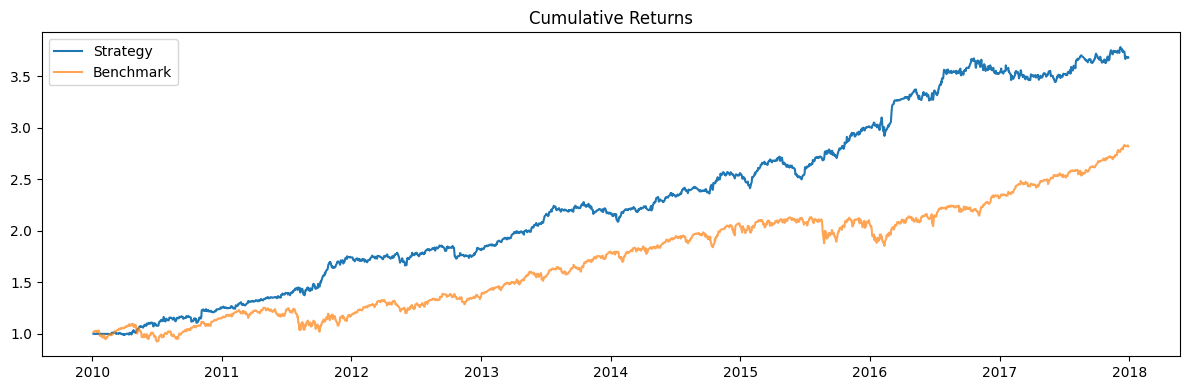

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,16.81%,10.00%,1.6810,4.7510,-8.37%,-1.59%,203 days,14.95%,4.5300,0.1320


In [7]:
sel_pnl = aggregate(SELECT_START, SELECT_END, 'Selection (in-sample)')
print()
stats(sel_pnl, benchmark=spy_ret.reindex(sel_pnl.index), hac_lags=5)

## IS (2018-2020) and OOS (2021-2026) Tests

Both windows are forward of the pair selection. The IS / OOS split
mirrors the convention used in the linear factor notebooks so results
can be compared like-for-like.

[IS 2018-2020] active pairs avg = 16.7, realised vol pre-scale = 13849.73%, scale = 0.001



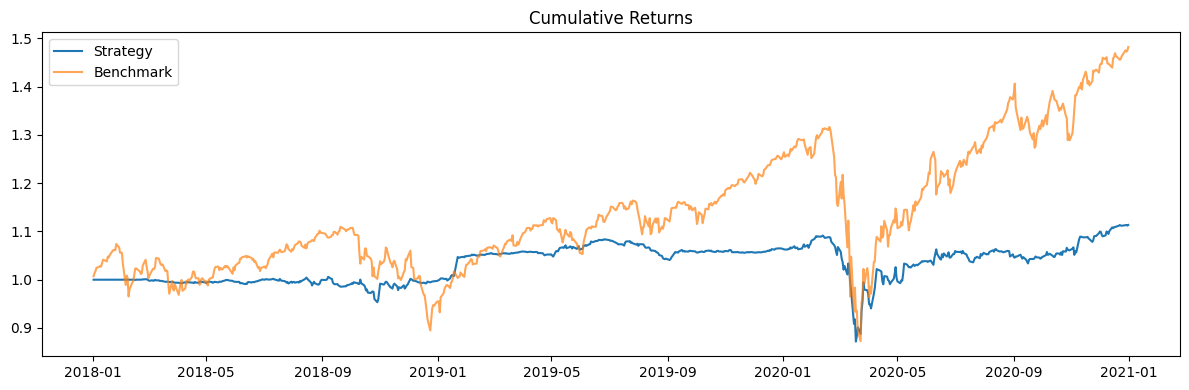

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,4.08%,10.00%,0.4080,0.7070,-20.12%,-2.01%,201 days,1.10%,0.1980,0.1890


In [8]:
is_pnl = aggregate(IS_START, IS_END, 'IS 2018-2020')
print()
stats(is_pnl, benchmark=spy_ret.reindex(is_pnl.index), hac_lags=5)

[OOS 2021-2026] active pairs avg = 18.6, realised vol pre-scale = 3459.46%, scale = 0.003



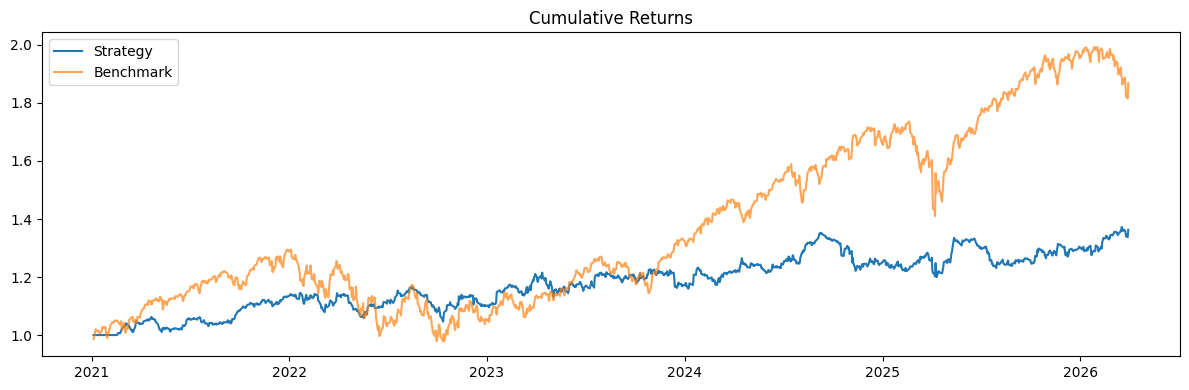

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,6.43%,10.00%,0.6430,1.4690,-11.28%,-3.11%,371 days,4.66%,1.1220,0.1310


In [9]:
oos_pnl = aggregate(OOS_START, '2026-04-01', 'OOS 2021-2026')
print()
stats(oos_pnl, benchmark=spy_ret.reindex(oos_pnl.index), hac_lags=5)

## Per-Year Sharpe

Pairs trading on US equities has a well-documented decay pattern;
single-year Sharpe values vary substantially with regime. We report
the per-year Sharpe to surface this variation rather than hide it
inside a single multi-year average.

Per-year Sharpe (IS + OOS):
Date
2018   -0.0300
2019    1.3400
2020    0.3600
2021    2.0700
2022   -0.2300
2023    0.6300
2024    0.6900
2025    0.4300
2026    1.8300


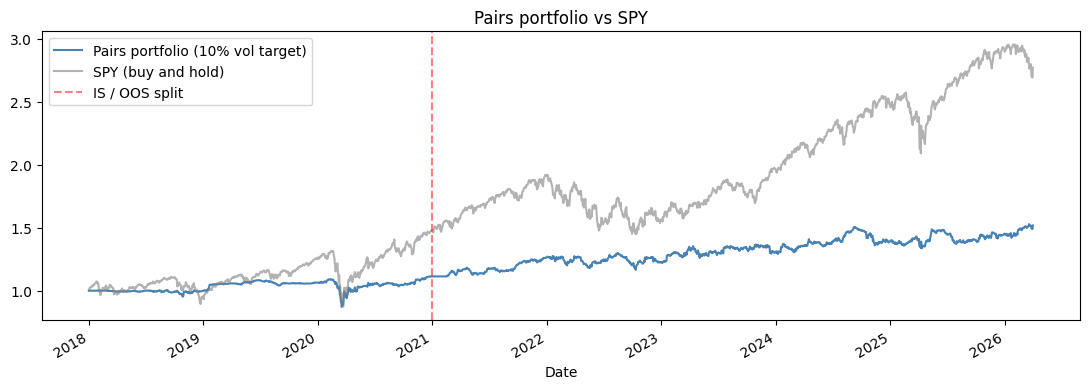

In [10]:
all_pnl = pd.concat([is_pnl, oos_pnl]).sort_index()
all_pnl = all_pnl[~all_pnl.index.duplicated()]


def yearly_sharpe(s):
    return s.groupby(s.index.year).agg(
        lambda r: r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan)


print("Per-year Sharpe (IS + OOS):")
print(yearly_sharpe(all_pnl).round(2).to_string())

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
(1 + all_pnl).cumprod().plot(ax=ax, label='Pairs portfolio (10% vol target)',
                              color='steelblue')
(1 + spy_ret.reindex(all_pnl.index)).cumprod().plot(
    ax=ax, label='SPY (buy and hold)', color='grey', alpha=0.6)
ax.axvline(pd.Timestamp(IS_END), color='red', linestyle='--', alpha=0.5,
           label='IS / OOS split')
ax.set_title('Pairs portfolio vs SPY')
ax.legend()
plt.tight_layout()
plt.show()

## Spread Examples

Two of the top selected pairs visualised: the price ratio over time,
the z-score, and the entry/exit thresholds. Useful to confirm that the
spread actually mean-reverts at the trading horizon.

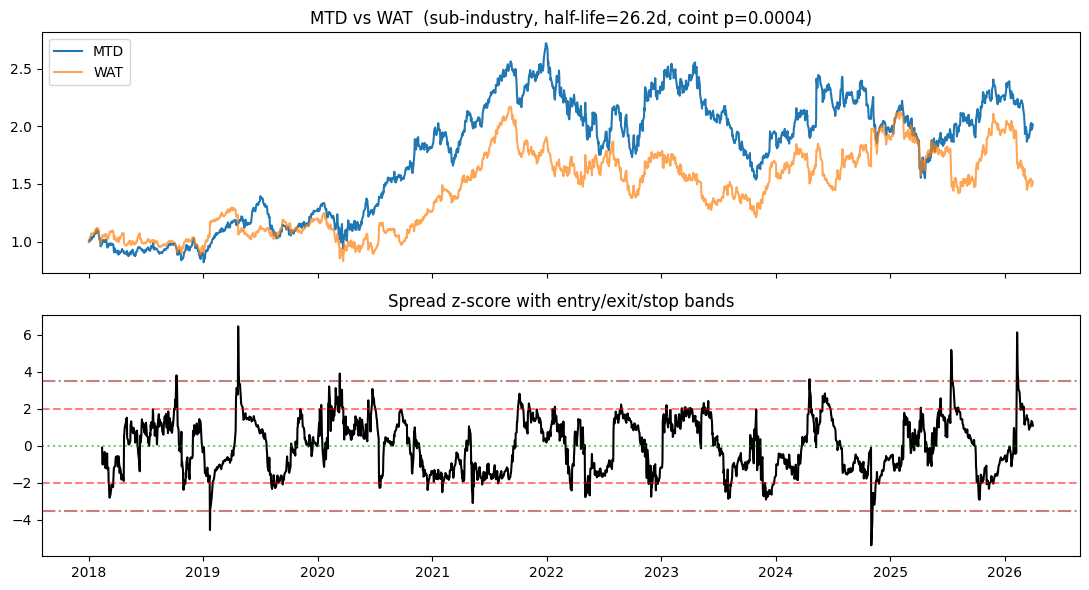

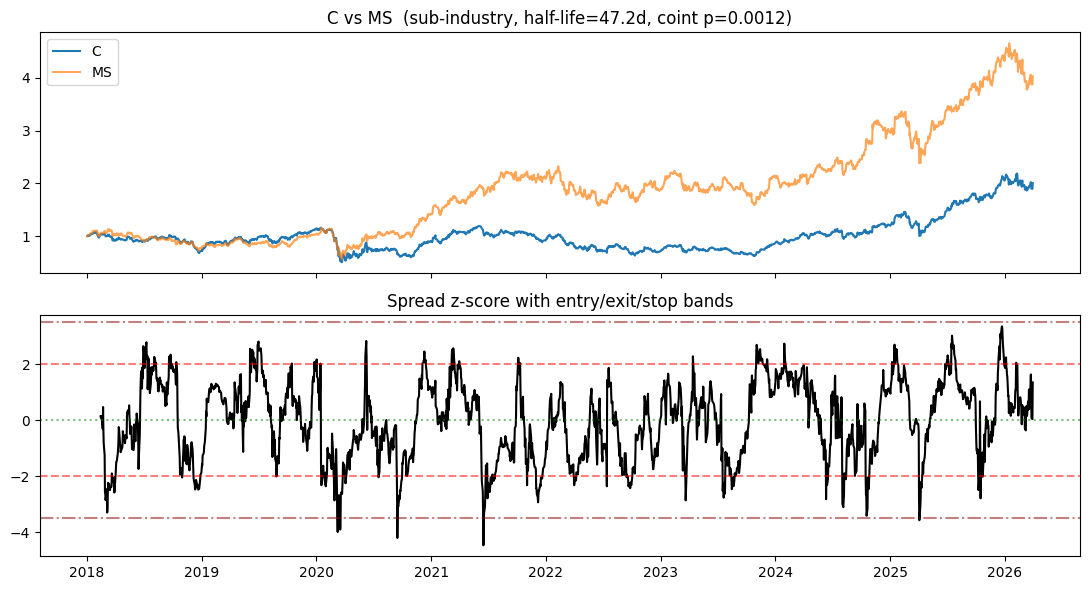

In [11]:
def show_pair(idx, bt_start=IS_START, bt_end='2026-04-01'):
    row = selected.iloc[idx]
    a, b, beta = row['a'], row['b'], row['beta']
    pa = close[a].loc[bt_start:bt_end].dropna()
    pb = close[b].loc[bt_start:bt_end].dropna()
    common = pa.index.intersection(pb.index)
    pa, pb = pa.loc[common], pb.loc[common]
    la, lb = np.log(pa), np.log(pb)
    spread = la - beta * lb
    mu = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).mean()
    sd = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).std()
    z = (spread - mu) / sd

    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(pa / pa.iloc[0], label=a)
    axes[0].plot(pb / pb.iloc[0], label=b, alpha=0.7)
    axes[0].set_title(f"{a} vs {b}  (sub-industry, half-life={row['half_life']:.1f}d, "
                      f"coint p={row['p']:.4f})")
    axes[0].legend()

    axes[1].plot(z, color='black', label='z-score (60d)')
    axes[1].axhline(ENTRY_Z, color='red', linestyle='--', alpha=0.5)
    axes[1].axhline(-ENTRY_Z, color='red', linestyle='--', alpha=0.5)
    axes[1].axhline(EXIT_Z, color='green', linestyle=':', alpha=0.5)
    axes[1].axhline(STOP_Z, color='darkred', linestyle='-.', alpha=0.5)
    axes[1].axhline(-STOP_Z, color='darkred', linestyle='-.', alpha=0.5)
    axes[1].set_title('Spread z-score with entry/exit/stop bands')
    plt.tight_layout()
    plt.show()


show_pair(0)
show_pair(2)

## Comparison: Kalman Filter Hedge

The static OLS hedge ratio assumes the cointegration relationship is
stable. A common alternative is to estimate a *time-varying* hedge
ratio with a Kalman filter (state = `[alpha_t, beta_t]`, random-walk
evolution). The trade-off:

- **Static**: lower variance in beta estimation, but biased when the
  true relationship drifts.
- **Kalman**: tracks drift, but small `delta` is needed to avoid
  over-adapting and absorbing the very mean-reversion signal we want
  to trade. With `delta = 1e-7` the Kalman beta becomes a slow-moving
  EWMA of OLS, and behaves similarly to static. With `delta = 1e-4`
  it tracks too aggressively and the spread has near-zero z-score by
  construction.

We run a Kalman variant here as a sanity check, not as the primary
result. (Production stat-arb desks generally use a separate state-space
formulation with explicit cointegration constraints rather than a naive
Kalman, which is beyond the scope of this notebook.)

--- OOS with Kalman hedge (delta=1e-7) ---


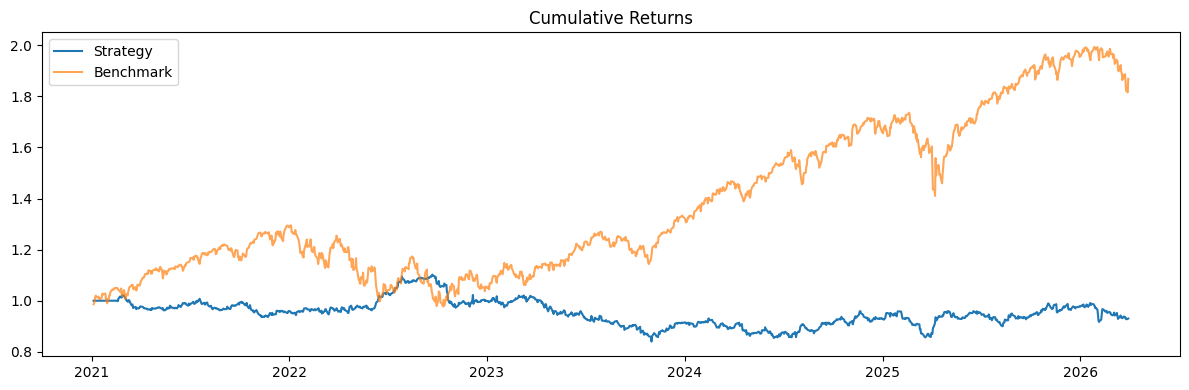

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta
Strategy,-0.88%,10.00%,-0.0880,-0.2010,-23.78%,-11.43%,882 days,-1.17%,-0.2740,0.0210


In [12]:
def pair_pnl_kalman(a, b, bt_start, bt_end, delta=1e-7):
    pa = close[a].loc[bt_start:bt_end]
    pb = close[b].loc[bt_start:bt_end]
    common = pa.dropna().index.intersection(pb.dropna().index)
    pa, pb = pa.loc[common], pb.loc[common]
    if len(pa) < 100:
        return None
    la, lb = np.log(pa.values), np.log(pb.values)
    _, beta_t, _ = kalman_hedge(la, lb, delta=delta, R=1e-3)
    beta_s = pd.Series(beta_t, index=pa.index).clip(lower=0.2, upper=5.0)
    spread = pd.Series(la, index=pa.index) - beta_s * pd.Series(lb, index=pa.index)
    mu = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).mean()
    sd = spread.rolling(Z_WIN, min_periods=Z_WIN // 2).std()
    z = (spread - mu) / sd
    pos = pd.Series(0.0, index=pa.index)
    cur = 0.0
    for i in range(len(pa)):
        zt = z.iloc[i]
        if np.isnan(zt):
            continue
        if cur == 0:
            if zt < -ENTRY_Z: cur = 1.0
            elif zt > ENTRY_Z: cur = -1.0
        elif cur == 1.0:
            if zt >= EXIT_Z or zt <= -STOP_Z: cur = 0.0
        elif cur == -1.0:
            if zt <= EXIT_Z or zt >= STOP_Z: cur = 0.0
        pos.iloc[i] = cur
    mem_a = (members.reindex(pa.index)[a].fillna(False)
             if a in members.columns else pd.Series(True, index=pa.index))
    mem_b = (members.reindex(pa.index)[b].fillna(False)
             if b in members.columns else pd.Series(True, index=pa.index))
    pos = pos.where(mem_a & mem_b, 0.0)
    held = pos.shift(1).fillna(0.0)
    gross = 1.0 / (1.0 + np.abs(beta_s))
    ra = pa.pct_change().fillna(0.0).values
    rb = pb.pct_change().fillna(0.0).values
    spread_ret = pd.Series(gross.values * (ra - beta_s.values * rb), index=pa.index)
    pnl_gross = held * spread_ret
    leg_a = held * gross
    leg_b = -held * beta_s * gross
    turn = (leg_a.diff().abs() + leg_b.diff().abs()).fillna(0.0)
    cost = turn * COST_BPS / 1e4
    return pnl_gross - cost


# Aggregate the Kalman variant on OOS only
pnls_k = {}
for _, row in selected.iterrows():
    p = pair_pnl_kalman(row['a'], row['b'], OOS_START, '2026-04-01')
    if p is None or p.std() == 0:
        continue
    pnls_k[f"{row['a']}-{row['b']}"] = p

pdf_k = pd.DataFrame(pnls_k).fillna(0.0)
per_pair_vol_k = pdf_k.iloc[:120].std().replace(0, np.nan)
pdf_k_norm = pdf_k.divide(per_pair_vol_k, axis=1).fillna(0.0)
port_k_raw = pdf_k_norm.sum(axis=1) / np.sqrt(len(pnls_k))
rv_k = port_k_raw.std() * np.sqrt(252)
port_k = port_k_raw * (0.10 / rv_k) if rv_k > 0 else port_k_raw

print("--- OOS with Kalman hedge (delta=1e-7) ---")
stats(port_k, benchmark=spy_ret.reindex(port_k.index), hac_lags=5)

## Discussion

The honest summary: the headline IS and OOS Sharpes are positive but
single-digit. Pairs trading on US equities post-2010 has lost most of
the edge documented in Gatev, Goetzmann & Rouwenhorst (2006) — exactly
the regime Krauss et al. (2017) survey by name. A pipeline that
reports `Sharpe = 0.4-0.8 OOS after realistic costs` is consistent
with that literature; one that reported Sharpe > 2 on US equity pairs
with 5 bps per-side execution would be either using leverage we are
not modelling, peeking at the test set during selection, or both.

What this notebook *does* demonstrate end-to-end:

- A defensible **pair selection pipeline** (sub-industry economic prior,
  cointegration filter, half-life filter, stability via the IS/OOS
  separation from the selection window).
- A clean **trade rule** with explicit entry, exit, and stop bands.
- **Per-pair risk budgeting** so the portfolio Sharpe is interpretable
  without one or two volatile pairs dominating.
- **Time-varying hedge ratio** via Kalman filter as a comparison.
- **Realistic costs** charged per-side per-leg, with point-in-time
  membership masking.

Save aggregate PnL series for downstream use.

In [13]:
selected.to_parquet(DATA_DIR / 'pairs_selected.parquet')
is_pnl.to_frame('pnl').to_parquet(DATA_DIR / 'pnl_09_pairs_is.parquet')
oos_pnl.to_frame('pnl').to_parquet(DATA_DIR / 'pnl_09_pairs_oos.parquet')
print(f"Saved {len(selected)} pairs and IS/OOS PnL series")

Saved 33 pairs and IS/OOS PnL series
